## Imports

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import BaggingClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
import optuna
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
train_df = pd.read_csv('train_c.csv')
test_df = pd.read_csv('test_c.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
train_df.head()


Train shape: (11017, 35)
Test shape: (5000, 35)


,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,...,JobTenure,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved
0,2010-06-26,27.0,66829.0,549.0,17290.0,60.0,Divorced,1.0,Rent,1095.0,...,4.0,Employed,Associate,4.0,35067.0,0.257790,0.251465,508.970230,0.288013,0.0
1,1996-09-23,55.0,172147.0,850.0,16110.0,36.0,Widowed,1.0,Mortgage,211.0,...,2.0,Employed,High School,33.0,27001.0,0.086110,0.093173,514.675859,0.050585,1.0
2,2015-01-19,51.0,300000.0,850.0,38436.0,36.0,Married,0.0,Mortgage,546.0,...,3.0,Employed,Bachelor,28.0,278382.0,0.108436,0.115443,1268.276385,0.072571,1.0
3,1981-05-12,25.0,34683.0,847.0,19186.0,48.0,Married,0.0,Other,153.0,...,3.0,Employed,High School,0.0,9224.0,0.100686,0.112822,498.505187,0.225415,1.0
4,1995-05-07,55.0,300000.0,850.0,30437.0,48.0,Single,2.0,Rent,562.0,...,5.0,Employed,Bachelor,31.0,4502.0,0.110437,0.089037,756.035156,0.052721,1.0


## EDA

In [35]:
train_df.columns

Index(['ApplicationDate', 'Age', 'AnnualIncome', 'CreditScore', 'LoanAmount',
       'LoanDuration', 'MaritalStatus', 'NumberOfDependents',
       'HomeOwnershipStatus', 'MonthlyDebtPayments',
       'CreditCardUtilizationRate', 'NumberOfOpenCreditLines',
       'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory',
       'LoanPurpose', 'PreviousLoanDefaults', 'PaymentHistory',
       'LengthOfCreditHistory', 'SavingsAccountBalance',
       'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities',
       'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure',
       'EmploymentStatus', 'EducationLevel', 'Experience', 'NetWorth',
       'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment',
       'TotalDebtToIncomeRatio', 'LoanApproved'],
      dtype='object')

In [34]:
test_df.columns

Index(['ID', 'ApplicationDate', 'Age', 'AnnualIncome', 'CreditScore',
       'LoanAmount', 'LoanDuration', 'MaritalStatus', 'NumberOfDependents',
       'HomeOwnershipStatus', 'MonthlyDebtPayments',
       'CreditCardUtilizationRate', 'NumberOfOpenCreditLines',
       'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory',
       'LoanPurpose', 'PreviousLoanDefaults', 'PaymentHistory',
       'LengthOfCreditHistory', 'SavingsAccountBalance',
       'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities',
       'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure',
       'EmploymentStatus', 'EducationLevel', 'Experience', 'NetWorth',
       'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment',
       'TotalDebtToIncomeRatio'],
      dtype='object')

In [10]:
print(train_df.info())
print(train_df.describe())
print(train_df.isnull().sum())
print(train_df['LoanApproved'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11017 entries, 0 to 11016
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             10487 non-null  object 
 1   Age                         10487 non-null  float64
 2   AnnualIncome                10487 non-null  float64
 3   CreditScore                 9986 non-null   float64
 4   LoanAmount                  9986 non-null   float64
 5   LoanDuration                10487 non-null  float64
 6   MaritalStatus               10487 non-null  object 
 7   NumberOfDependents          10487 non-null  float64
 8   HomeOwnershipStatus         10487 non-null  object 
 9   MonthlyDebtPayments         9986 non-null   float64
 10  CreditCardUtilizationRate   10487 non-null  float64
 11  NumberOfOpenCreditLines     10487 non-null  float64
 12  NumberOfCreditInquiries     10487 non-null  float64
 13  DebtToIncomeRatio           104

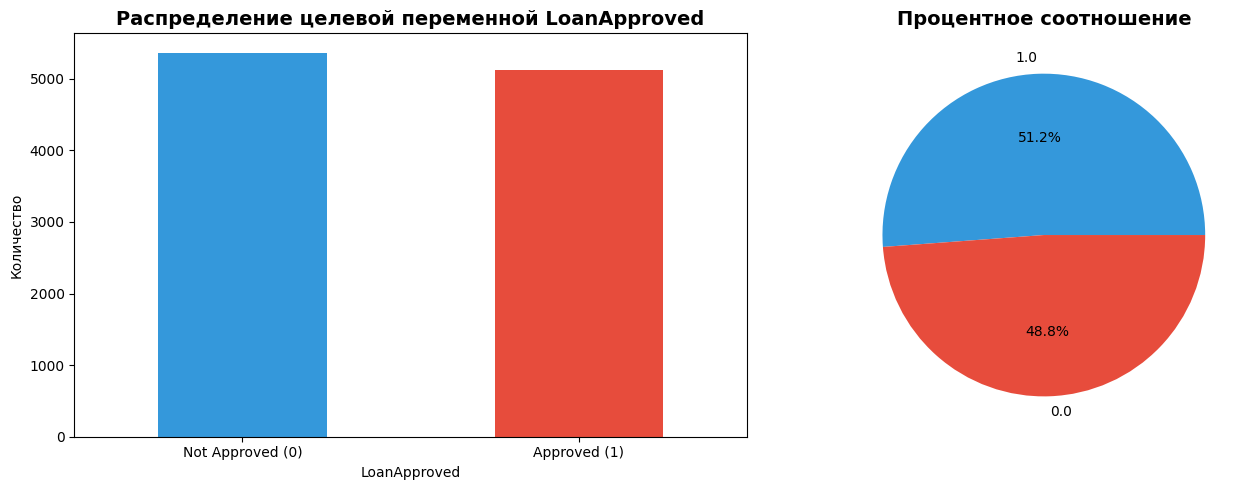

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_df['LoanApproved'].value_counts().plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'])
axes[0].set_title('Распределение целевой переменной LoanApproved', fontsize=14, fontweight='bold')
axes[0].set_xlabel('LoanApproved')
axes[0].set_ylabel('Количество')
axes[0].set_xticklabels(['Not Approved (0)', 'Approved (1)'], rotation=0)

train_df['LoanApproved'].value_counts(normalize=True).plot(kind='pie', ax=axes[1], 
                                                             autopct='%1.1f%%',
                                                             colors=['#3498db', '#e74c3c'])
axes[1].set_title('Процентное соотношение', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

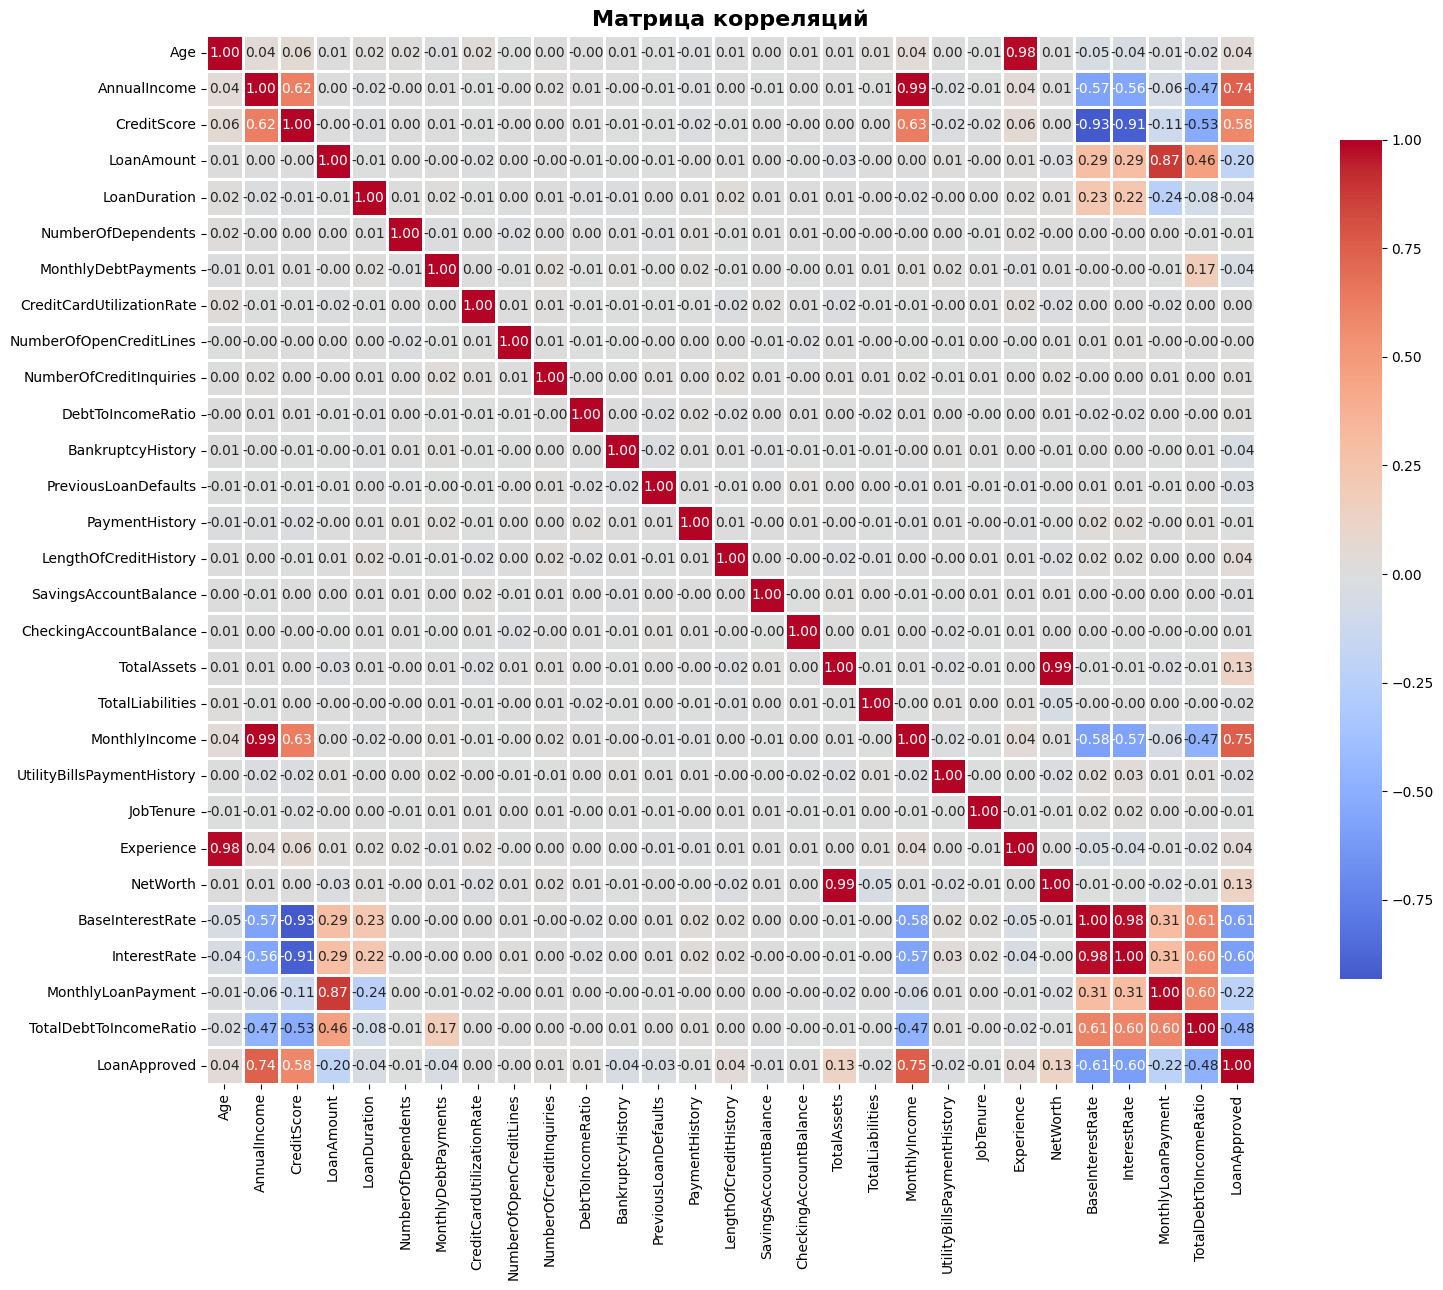

LoanApproved                  1.000000
MonthlyIncome                 0.754853
AnnualIncome                  0.743034
CreditScore                   0.581812
NetWorth                      0.129624
TotalAssets                   0.129204
LengthOfCreditHistory         0.038509
Experience                    0.036699
Age                           0.036580
DebtToIncomeRatio             0.014922
NumberOfCreditInquiries       0.012520
CheckingAccountBalance        0.009503
CreditCardUtilizationRate     0.003731
NumberOfOpenCreditLines      -0.001003
NumberOfDependents           -0.007421
JobTenure                    -0.007951
PaymentHistory               -0.010064
SavingsAccountBalance        -0.011804
TotalLiabilities             -0.015154
UtilityBillsPaymentHistory   -0.020812
PreviousLoanDefaults         -0.029994
LoanDuration                 -0.039908
BankruptcyHistory            -0.042160
MonthlyDebtPayments          -0.044257
LoanAmount                   -0.195607
MonthlyLoanPayment       

In [13]:
plt.figure(figsize=(18, 13))
numeric_cols = train_df.select_dtypes(include=[np.number]).columns
correlation_matrix = train_df[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Матрица корреляций', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

target_corr = correlation_matrix['LoanApproved'].sort_values(ascending=False)
print(target_corr)

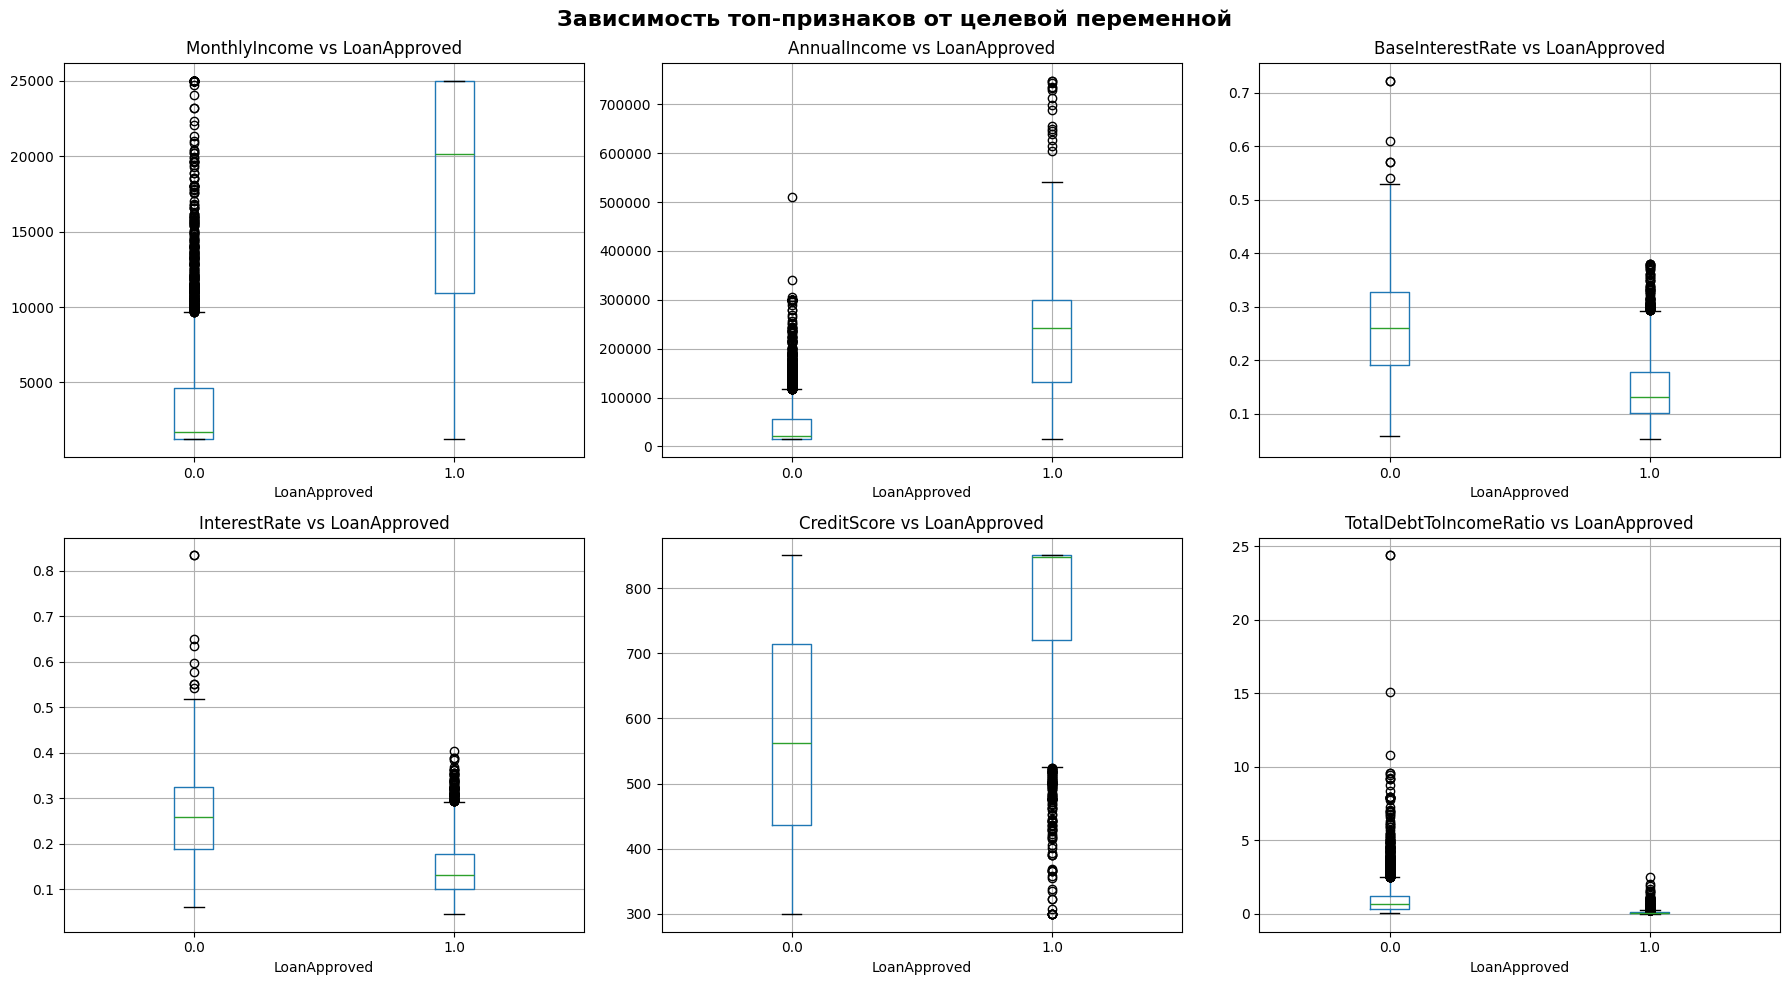

In [14]:
numeric_features = train_df.select_dtypes(include=[np.number]).columns.drop('LoanApproved')

top_features = target_corr.abs().sort_values(ascending=False)[1:7].index

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, feature in enumerate(top_features):
    train_df.boxplot(column=feature, by='LoanApproved', ax=axes[idx])
    axes[idx].set_title(f'{feature} vs LoanApproved')
    axes[idx].set_xlabel('LoanApproved')
    
plt.suptitle('Зависимость топ-признаков от целевой переменной', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## Train

In [38]:
def prepare_data(df, is_train=True):
    df = df.copy()
    
    if 'ID' in df.columns:
        df = df.drop('ID', axis=1)
    
    for col in df.select_dtypes(include=[np.number]).columns:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].median(), inplace=True)
    
    for col in df.select_dtypes(include=['object']).columns:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].mode()[0], inplace=True)
    
    categorical_cols = df.select_dtypes(include=['object']).columns
    if is_train and 'LoanApproved' in categorical_cols:
        categorical_cols = categorical_cols.drop('LoanApproved')
    
    for col in categorical_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
    
    return df

train_processed = prepare_data(train_df, is_train=True)
test_processed = prepare_data(test_df, is_train=False)

print(f"Train columns: {len(train_processed.columns)}")
print(f"Test columns: {len(test_processed.columns)}")

X = train_processed.drop('LoanApproved', axis=1)
y = train_processed['LoanApproved']

print(f"\nX shape: {X.shape}")
print(f"test_processed shape: {test_processed.shape}")
assert X.shape[1] == test_processed.shape[1], "Количество признаков не совпадает!"

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nX_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_train distribution:\n{y_train.value_counts()}")


Train columns: 35
Test columns: 34

X shape: (11017, 34)
test_processed shape: (5000, 34)

X_train shape: (8813, 34)
X_val shape: (2204, 34)
y_train distribution:
LoanApproved
1.0    4717
0.0    4096
Name: count, dtype: int64


In [16]:
class CustomBaggingClassifier:
    def __init__(self, base_estimator=None, n_estimators=10, max_samples=1.0, random_state=None):
        self.base_estimator = base_estimator if base_estimator else DecisionTreeClassifier()
        self.n_estimators = n_estimators
        self.max_samples = max_samples
        self.random_state = random_state
        self.estimators_ = []
        self.samples_indices_ = []
        
    def fit(self, X, y):
        np.random.seed(self.random_state)
        n_samples = int(len(X) * self.max_samples)
        
        X_array = X.values if hasattr(X, 'values') else X
        y_array = y.values if hasattr(y, 'values') else y
        
        self.estimators_ = []
        self.samples_indices_ = []
        
        for i in range(self.n_estimators):
            indices = np.random.choice(len(X_array), size=n_samples, replace=True)
            self.samples_indices_.append(indices)
            
            estimator = self._clone_estimator()
            estimator.fit(X_array[indices], y_array[indices])
            self.estimators_.append(estimator)
            
        return self
    
    def _clone_estimator(self):
        from sklearn.base import clone
        return clone(self.base_estimator)
    
    def predict_proba(self, X):
        X_array = X.values if hasattr(X, 'values') else X
        
        predictions = np.array([est.predict_proba(X_array) for est in self.estimators_])
        
        return np.mean(predictions, axis=0)
    
    def predict(self, X):
        proba = self.predict_proba(X)
        return (proba[:, 1] > 0.5).astype(int)

In [17]:
custom_bagging = CustomBaggingClassifier(
    base_estimator=DecisionTreeClassifier(max_depth=5, random_state=42),
    n_estimators=50,
    max_samples=0.8,
    random_state=42
)
custom_bagging.fit(X_train, y_train)

y_pred_custom = custom_bagging.predict(X_val)
y_proba_custom = custom_bagging.predict_proba(X_val)[:, 1]

sklearn_bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=5, random_state=42),
    n_estimators=50,
    max_samples=0.8,
    random_state=42
)
sklearn_bagging.fit(X_train, y_train)

y_pred_sklearn = sklearn_bagging.predict(X_val)
y_proba_sklearn = sklearn_bagging.predict_proba(X_val)[:, 1]

print("Custom Bagging:")
print(f"  Accuracy: {accuracy_score(y_val, y_pred_custom):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_val, y_proba_custom):.4f}")
print(f"  Precision: {precision_score(y_val, y_pred_custom):.4f}")
print(f"  Recall: {recall_score(y_val, y_pred_custom):.4f}")
print(f"  F1-Score: {f1_score(y_val, y_pred_custom):.4f}")

print("\nSklearn Bagging:")
print(f"  Accuracy: {accuracy_score(y_val, y_pred_sklearn):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_val, y_proba_sklearn):.4f}")
print(f"  Precision: {precision_score(y_val, y_pred_sklearn):.4f}")
print(f"  Recall: {recall_score(y_val, y_pred_sklearn):.4f}")
print(f"  F1-Score: {f1_score(y_val, y_pred_sklearn):.4f}")


Custom Bagging:
  Accuracy: 0.9220
  ROC-AUC: 0.9776
  Precision: 0.9186
  Recall: 0.9373
  F1-Score: 0.9279

Sklearn Bagging:
  Accuracy: 0.9183
  ROC-AUC: 0.9771
  Precision: 0.9146
  Recall: 0.9347
  F1-Score: 0.9246


In [18]:
from sklearn.tree import DecisionTreeRegressor

class CustomGradientBoostingClassifier:
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3, random_state=None):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.random_state = random_state
        self.estimators_ = []
        self.initial_prediction_ = None
        
    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
    
    def _log_odds(self, prob):
        prob = np.clip(prob, 1e-7, 1 - 1e-7)
        return np.log(prob / (1 - prob))
    
    def fit(self, X, y):
        X_array = X.values if hasattr(X, 'values') else X
        y_array = y.values if hasattr(y, 'values') else y
        
        mean_prob = np.mean(y_array)
        self.initial_prediction_ = self._log_odds(mean_prob)
        
        current_predictions = np.full(len(y_array), self.initial_prediction_)
        
        self.estimators_ = []
        
        for i in range(self.n_estimators):
            probabilities = self._sigmoid(current_predictions)
            residuals = y_array - probabilities
            
            tree = DecisionTreeRegressor(
                max_depth=self.max_depth,
                random_state=self.random_state + i if self.random_state else None
            )
            tree.fit(X_array, residuals)
            
            update = tree.predict(X_array)
            current_predictions += self.learning_rate * update
            
            self.estimators_.append(tree)
            
        return self
    
    def predict_proba(self, X):
        X_array = X.values if hasattr(X, 'values') else X
        
        predictions = np.full(len(X_array), self.initial_prediction_)
        
        for tree in self.estimators_:
            predictions += self.learning_rate * tree.predict(X_array)
        
        prob_class_1 = self._sigmoid(predictions)
        prob_class_0 = 1 - prob_class_1
        
        return np.column_stack([prob_class_0, prob_class_1])
    
    def predict(self, X):
        proba = self.predict_proba(X)
        return (proba[:, 1] > 0.5).astype(int)

In [19]:
custom_gb = CustomGradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
custom_gb.fit(X_train, y_train)

y_pred_custom_gb = custom_gb.predict(X_val)
y_proba_custom_gb = custom_gb.predict_proba(X_val)[:, 1]

sklearn_gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
sklearn_gb.fit(X_train, y_train)

y_pred_sklearn_gb = sklearn_gb.predict(X_val)
y_proba_sklearn_gb = sklearn_gb.predict_proba(X_val)[:, 1]

print("Custom Gradient Boosting:")
print(f"  Accuracy: {accuracy_score(y_val, y_pred_custom_gb):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_val, y_proba_custom_gb):.4f}")
print(f"  Precision: {precision_score(y_val, y_pred_custom_gb):.4f}")
print(f"  Recall: {recall_score(y_val, y_pred_custom_gb):.4f}")
print(f"  F1-Score: {f1_score(y_val, y_pred_custom_gb):.4f}")

print("\nSklearn Gradient Boosting:")
print(f"  Accuracy: {accuracy_score(y_val, y_pred_sklearn_gb):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_val, y_proba_sklearn_gb):.4f}")
print(f"  Precision: {precision_score(y_val, y_pred_sklearn_gb):.4f}")
print(f"  Recall: {recall_score(y_val, y_pred_sklearn_gb):.4f}")
print(f"  F1-Score: {f1_score(y_val, y_pred_sklearn_gb):.4f}")

Custom Gradient Boosting:
  Accuracy: 0.9201
  ROC-AUC: 0.9766
  Precision: 0.9169
  Recall: 0.9356
  F1-Score: 0.9262

Sklearn Gradient Boosting:
  Accuracy: 0.9283
  ROC-AUC: 0.9824
  Precision: 0.9280
  Recall: 0.9390
  F1-Score: 0.9334


In [22]:
results = {}

results['Sklearn GB'] = {
    'model': sklearn_gb,
    'accuracy': accuracy_score(y_val, y_pred_sklearn_gb),
    'roc_auc': roc_auc_score(y_val, y_proba_sklearn_gb),
    'precision': precision_score(y_val, y_pred_sklearn_gb),
    'recall': recall_score(y_val, y_pred_sklearn_gb),
    'f1': f1_score(y_val, y_pred_sklearn_gb)
}

lgb_model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    verbose=-1
)
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_val)
y_proba_lgb = lgb_model.predict_proba(X_val)[:, 1]

results['LightGBM'] = {
    'model': lgb_model,
    'accuracy': accuracy_score(y_val, y_pred_lgb),
    'roc_auc': roc_auc_score(y_val, y_proba_lgb),
    'precision': precision_score(y_val, y_pred_lgb),
    'recall': recall_score(y_val, y_pred_lgb),
    'f1': f1_score(y_val, y_pred_lgb)
}

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_val)
y_proba_xgb = xgb_model.predict_proba(X_val)[:, 1]

results['XGBoost'] = {
    'model': xgb_model,
    'accuracy': accuracy_score(y_val, y_pred_xgb),
    'roc_auc': roc_auc_score(y_val, y_proba_xgb),
    'precision': precision_score(y_val, y_pred_xgb),
    'recall': recall_score(y_val, y_pred_xgb),
    'f1': f1_score(y_val, y_pred_xgb)
}

cat_model = cb.CatBoostClassifier(
    iterations=100,
    learning_rate=0.1,
    depth=3,
    random_state=42,
    verbose=0
)
cat_model.fit(X_train, y_train)
y_pred_cat = cat_model.predict(X_val)
y_proba_cat = cat_model.predict_proba(X_val)[:, 1]

results['CatBoost'] = {
    'model': cat_model,
    'accuracy': accuracy_score(y_val, y_pred_cat),
    'roc_auc': roc_auc_score(y_val, y_proba_cat),
    'precision': precision_score(y_val, y_pred_cat),
    'recall': recall_score(y_val, y_pred_cat),
    'f1': f1_score(y_val, y_pred_cat)
}

comparison_df = pd.DataFrame(results).T
print(comparison_df.drop('model', axis=1))

best_model_name = comparison_df['roc_auc'].idxmax()
best_model = results[best_model_name]['model']
print(f"\nЛучшая модель: {best_model_name} с ROC-AUC = {results[best_model_name]['roc_auc']:.4f}")


            accuracy   roc_auc precision    recall        f1
Sklearn GB  0.928312  0.982377  0.927973  0.938983  0.933446
LightGBM    0.926044  0.982452  0.925523  0.937288  0.931368
XGBoost     0.923775  0.982178  0.921667  0.937288  0.929412
CatBoost    0.927405  0.981953  0.930743  0.933898  0.932318

Лучшая модель: LightGBM с ROC-AUC = 0.9825


In [23]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state': 42,
        'verbose': -1
    }
    
    model = lgb.LGBMClassifier(**params)
    model.fit(X_train, y_train)
    
    y_proba = model.predict_proba(X_val)[:, 1]
    roc_auc = roc_auc_score(y_val, y_proba)
    
    return roc_auc

study = optuna.create_study(direction='maximize', study_name='loan_approval')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Лучший ROC-AUC: {study.best_value:.4f}")
print(f"\nЛучшие гиперпараметры:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

best_params = study.best_params
best_params['random_state'] = 42
best_params['verbose'] = -1

final_model = lgb.LGBMClassifier(**best_params)
final_model.fit(X_train, y_train)

y_pred_final = final_model.predict(X_val)
y_proba_final = final_model.predict_proba(X_val)[:, 1]

print(f"Accuracy: {accuracy_score(y_val, y_pred_final):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, y_proba_final):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_final):.4f}")
print(f"Recall: {recall_score(y_val, y_pred_final):.4f}")
print(f"F1-Score: {f1_score(y_val, y_pred_final):.4f}")


[I 2025-12-13 14:59:51,748] A new study created in memory with name: loan_approval


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-13 14:59:52,543] Trial 0 finished with value: 0.9833760924258474 and parameters: {'n_estimators': 268, 'learning_rate': 0.13855299599220985, 'max_depth': 8, 'num_leaves': 79, 'min_child_samples': 29, 'subsample': 0.9624829403448453, 'colsample_bytree': 0.9106812103262321, 'reg_alpha': 0.35011530508669697, 'reg_lambda': 0.18328456864157405}. Best is trial 0 with value: 0.9833760924258474.
[I 2025-12-13 14:59:52,836] Trial 1 finished with value: 0.9834224377648306 and parameters: {'n_estimators': 185, 'learning_rate': 0.24879164054734335, 'max_depth': 6, 'num_leaves': 21, 'min_child_samples': 19, 'subsample': 0.7027172091876099, 'colsample_bytree': 0.8898294927045729, 'reg_alpha': 0.7194060940500424, 'reg_lambda': 0.2160121911747167}. Best is trial 1 with value: 0.9834224377648306.
[I 2025-12-13 14:59:52,940] Trial 2 finished with value: 0.9811705508474576 and parameters: {'n_estimators': 64, 'learning_rate': 0.2557510803541489, 'max_depth': 5, 'num_leaves': 35, 'min_child_sam

In [25]:
def custom_accuracy(y_true, y_pred):
    """
    Accuracy = (TP + TN) / (TP + TN + FP + FN)
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    correct = np.sum(y_true == y_pred)
    total = len(y_true)
    
    return correct / total

y_pred_test = final_model.predict(X_val)

custom_acc = custom_accuracy(y_val, y_pred_test)
sklearn_acc = accuracy_score(y_val, y_pred_test)

print(f"Custom Accuracy:  {custom_acc:.6f}")
print(f"Sklearn Accuracy: {sklearn_acc:.6f}")

Custom Accuracy:  0.932849
Sklearn Accuracy: 0.932849


In [26]:
def custom_precision(y_true, y_pred, pos_label=1):
    """
    Precision = TP / (TP + FP)
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    tp = np.sum((y_true == pos_label) & (y_pred == pos_label))
    
    fp = np.sum((y_true != pos_label) & (y_pred == pos_label))
    
    if tp + fp == 0:
        return 0.0
    
    return tp / (tp + fp)

custom_prec = custom_precision(y_val, y_pred_test)
sklearn_prec = precision_score(y_val, y_pred_test)

print(f"Custom Precision:  {custom_prec:.6f}")
print(f"Sklearn Precision: {sklearn_prec:.6f}")

Custom Precision:  0.933613
Sklearn Precision: 0.933613


In [27]:
def custom_recall(y_true, y_pred, pos_label=1):
    """
    Recall = TP / (TP + FN)
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    tp = np.sum((y_true == pos_label) & (y_pred == pos_label))
    
    fn = np.sum((y_true == pos_label) & (y_pred != pos_label))
    
    if tp + fn == 0:
        return 0.0
    
    return tp / (tp + fn)

custom_rec = custom_recall(y_val, y_pred_test)
sklearn_rec = recall_score(y_val, y_pred_test)

print(f"Custom Recall:  {custom_rec:.6f}")
print(f"Sklearn Recall: {sklearn_rec:.6f}")

Custom Recall:  0.941525
Sklearn Recall: 0.941525


In [28]:
def custom_f1_score(y_true, y_pred, pos_label=1):
    """
    F1 = 2 * (Precision * Recall) / (Precision + Recall)
    """
    precision = custom_precision(y_true, y_pred, pos_label)
    recall = custom_recall(y_true, y_pred, pos_label)
    
    if precision + recall == 0:
        return 0.0
    
    return 2 * (precision * recall) / (precision + recall)

custom_f1 = custom_f1_score(y_val, y_pred_test)
sklearn_f1 = f1_score(y_val, y_pred_test)

print(f"Custom F1-Score:  {custom_f1:.6f}")
print(f"Sklearn F1-Score: {sklearn_f1:.6f}")

Custom F1-Score:  0.937553
Sklearn F1-Score: 0.937553


In [30]:
def custom_roc_auc(y_true, y_proba):
    y_true = np.array(y_true)
    y_proba = np.array(y_proba)
    
    desc_score_indices = np.argsort(y_proba)[::-1]
    y_true_sorted = y_true[desc_score_indices]
    y_proba_sorted = y_proba[desc_score_indices]
    
    n_pos = np.sum(y_true == 1)
    n_neg = np.sum(y_true == 0)
    
    if n_pos == 0 or n_neg == 0:
        return 0.5
    
    tpr_list = []
    fpr_list = []
    
    tp = 0
    fp = 0
    
    for i in range(len(y_true_sorted)):
        if y_true_sorted[i] == 1:
            tp += 1
        else:
            fp += 1
        
        tpr = tp / n_pos
        fpr = fp / n_neg
        
        tpr_list.append(tpr)
        fpr_list.append(fpr)
    
    tpr_list = [0] + tpr_list
    fpr_list = [0] + fpr_list
    
    auc = 0.0
    for i in range(1, len(fpr_list)):
        auc += (fpr_list[i] - fpr_list[i-1]) * (tpr_list[i] + tpr_list[i-1]) / 2
    
    return auc

y_proba_test = final_model.predict_proba(X_val)[:, 1]

custom_auc_roc = custom_roc_auc(y_val, y_proba_test)
sklearn_auc_roc = roc_auc_score(y_val, y_proba_test)

print(f"Custom ROC-AUC:  {custom_auc_roc:.6f}")
print(f"Sklearn ROC-AUC: {sklearn_auc_roc:.6f}")


Custom ROC-AUC:  0.984408
Sklearn ROC-AUC: 0.984408


In [31]:
def custom_pr_auc(y_true, y_proba):
    y_true = np.array(y_true)
    y_proba = np.array(y_proba)
    
    desc_score_indices = np.argsort(y_proba)[::-1]
    y_true_sorted = y_true[desc_score_indices]
    
    n_pos = np.sum(y_true == 1)
    
    if n_pos == 0:
        return 0.0
    
    precision_list = []
    recall_list = []
    
    tp = 0
    fp = 0
    
    for i in range(len(y_true_sorted)):
        if y_true_sorted[i] == 1:
            tp += 1
        else:
            fp += 1
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / n_pos
        
        precision_list.append(precision)
        recall_list.append(recall)
    
    sorted_indices = np.argsort(recall_list)
    recall_sorted = np.array(recall_list)[sorted_indices]
    precision_sorted = np.array(precision_list)[sorted_indices]
    
    auc_pr = 0.0
    for i in range(1, len(recall_sorted)):
        auc_pr += (recall_sorted[i] - recall_sorted[i-1]) * (precision_sorted[i] + precision_sorted[i-1]) / 2
    
    return auc_pr

from sklearn.metrics import average_precision_score

custom_auc_pr = custom_pr_auc(y_val, y_proba_test)
sklearn_auc_pr = average_precision_score(y_val, y_proba_test)

print(f"Custom PR-AUC:  {custom_auc_pr:.6f}")
print(f"Sklearn PR-AUC: {sklearn_auc_pr:.6f}")


Custom PR-AUC:  0.986398
Sklearn PR-AUC: 0.987295


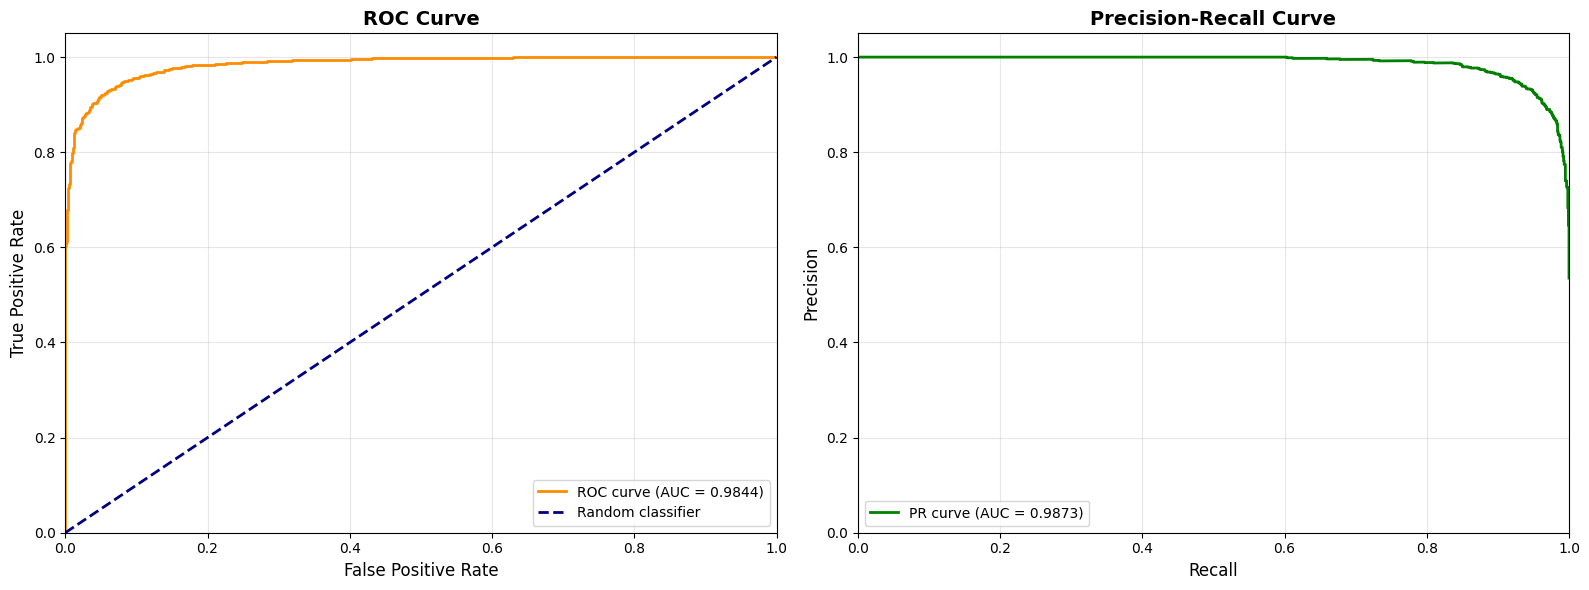

In [32]:
fpr, tpr, _ = roc_curve(y_val, y_proba_test)
roc_auc = auc(fpr, tpr)

precision_curve, recall_curve, _ = precision_recall_curve(y_val, y_proba_test)
pr_auc = auc(recall_curve, precision_curve)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

axes[1].plot(recall_curve, precision_curve, color='green', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower left")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [36]:
X_test.shape

(5000, 35)

In [37]:
X_train.shape

(8813, 34)

In [39]:
X_test = test_processed

test_predictions = final_model.predict_proba(X_test)[:, 1]

test_df_original = pd.read_csv('test_c.csv')

if 'ID' in test_df_original.columns:
    submission = pd.DataFrame({
        'ID': test_df_original['ID'],
        'LoanApproved': test_predictions
    })
else:
    submission = pd.DataFrame({
        'id': range(len(test_predictions)),
        'LoanApproved': test_predictions
    })

submission.to_csv('submission.csv', index=False)
print(f"\nПервые строки submission:")
print(submission.head(10))
print(f"\nСтатистика предсказаний:")
print(f"  Мин: {test_predictions.min():.4f}")
print(f"  Макс: {test_predictions.max():.4f}")
print(f"  Среднее: {test_predictions.mean():.4f}")



Первые строки submission:
   ID  LoanApproved
0   0      0.999956
1   1      0.000657
2   2      0.999865
3   3      0.999969
4   4      0.999909
5   5      0.000263
6   6      0.999985
7   7      0.999815
8   8      0.578382
9   9      0.000021

Статистика предсказаний:
  Мин: 0.0000
  Макс: 1.0000
  Среднее: 0.5208
